In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Load the dataset
df = pd.read_csv('heart.csv')

# Initial inspection
print("Dataset Overview:")
display(df.head())
print("\nColumn Information:")
df.info()

Dataset Overview:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## 1. Data Cleaning and Outlier Handling

In [3]:
# 1. Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# 2. Handle duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"\nRemoving {duplicates} duplicate rows...")
    df = df.drop_duplicates()

# 3. Outlier Handling (Interquartile Range method)
# We will focus on 'trestbps' (blood pressure) and 'chol' (cholesterol)
for col in ['trestbps', 'chol']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers to bounds (winsorization)
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

print("\nOutliers handled and duplicates removed.")
display(df.describe())

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Removing 723 duplicate rows...

Outliers handled and duplicates removed.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.258278,245.377070,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,16.605232,47.486683,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,170.000000,370.375000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 2. Feature Engineering



In [4]:
# 1. Create an 'age_group' feature (categorical)
df['is_elderly'] = (df['age'] > 60).astype(int)

# 2. Combined Risk Factor: High BP and High Cholesterol
# (Thresholds: Blood pressure > 140 OR Cholesterol > 240)
df['high_risk_profile'] = ((df['trestbps'] > 140) | (df['chol'] > 240)).astype(int)

print("New features created: 'is_elderly' and 'high_risk_profile'")
display(df[['age', 'is_elderly', 'trestbps', 'chol', 'high_risk_profile']].head())

New features created: 'is_elderly' and 'high_risk_profile'


,age,is_elderly,trestbps,chol,high_risk_profile
0,52,0,125.0,212.0,0
1,53,0,140.0,203.0,0
2,70,1,145.0,174.0,1
3,61,1,148.0,203.0,1
4,62,1,138.0,294.0,1


## 3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_7536/3151679084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='target', data=df, palette='viridis')


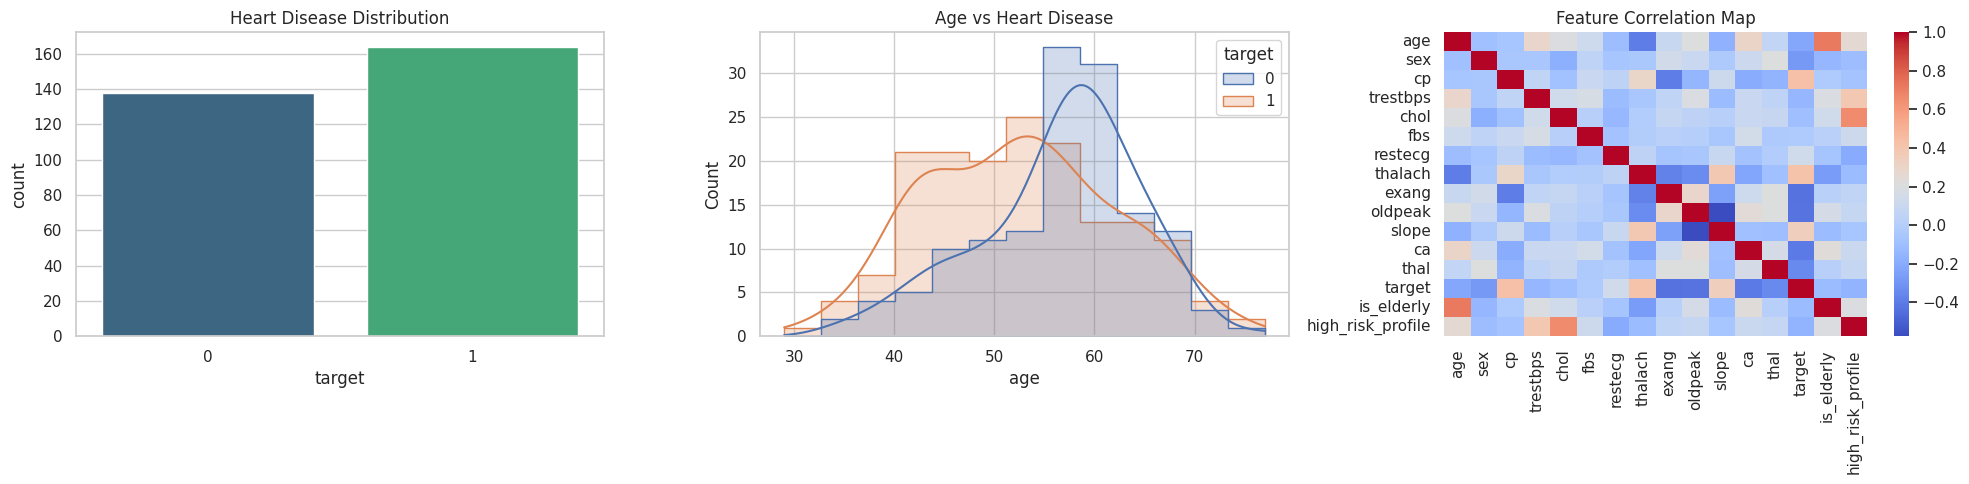

In [5]:
# EDA
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Target distribution
sns.countplot(ax=axes[0], x='target', data=df, palette='viridis')
axes[0].set_title('Heart Disease Distribution')

# Age distribution vs Target
sns.histplot(ax=axes[1], data=df, x='age', hue='target', kde=True, element="step")
axes[1].set_title('Age vs Heart Disease')

# Correlation heatmap
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Feature Correlation Map')

plt.tight_layout()
plt.show()

In [6]:
# Preprocessing
# Define features and target
X = df.drop('target', axis=1)
y = df['target']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize data (crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessing complete. Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Preprocessing complete. Training samples: 241, Testing samples: 61


## 4. Model Selection and Training

In [7]:
# Model Selection and Cross-Validation
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

print("Model Performance (5-Fold Cross-Validation Accuracy):")
results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = cv_scores.mean()
    print(f"{name}: {cv_scores.mean():.4f}")

best_model_name = max(results, key=results.get)
print(f"\nRecommended Model based on CV: {best_model_name}")

Model Performance (5-Fold Cross-Validation Accuracy):
Logistic Regression: 0.8216
Random Forest: 0.8215
SVM: 0.8090

Recommended Model based on CV: Logistic Regression


## 5. Final Evaluation

--- FINAL MODEL REPORT: LOGISTIC REGRESSION ---
Final Test Accuracy: 0.8197

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



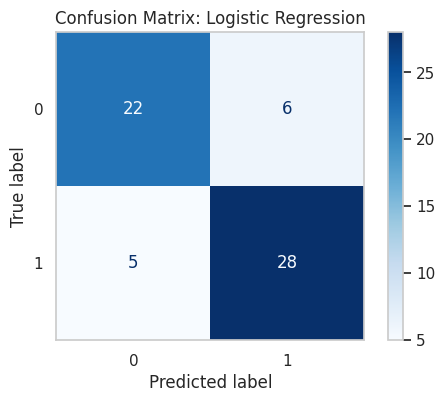

/tmp/ipykernel_7536/91129441.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Reds_r')


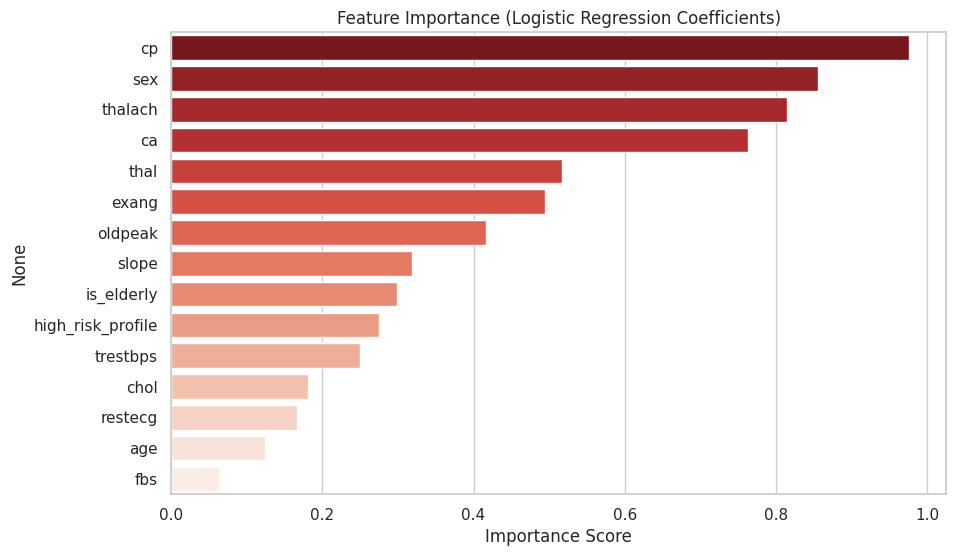

In [8]:
# Final Evaluation & Visual Results

# 1. Training the winning model dynamically based on CV results
if best_model_name == "Random Forest":
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
elif best_model_name == "Logistic Regression":
    final_model = LogisticRegression(random_state=42)
else:
    final_model = SVC(probability=True, random_state=42)

# Fit the model to the training data
final_model.fit(X_train_scaled, y_train)

# 2. Make predictions on the test set
y_pred = final_model.predict(X_test_scaled)

# 3. Print Metrics
print(f"--- FINAL MODEL REPORT: {best_model_name.upper()} ---")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Visual: Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(final_model, X_test_scaled, y_test, cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.grid(False) # Clean look
plt.show()

# 5. Visual: Feature Importance (Conditional)
# Note: Feature importance is directly available for Random Forest and Logistic Regression
if best_model_name == "Random Forest":
    importances = final_model.feature_importances_
    title = 'Feature Importance (Random Forest)'
elif best_model_name == "Logistic Regression":
    importances = np.abs(final_model.coef_[0])
    title = 'Feature Importance (Logistic Regression Coefficients)'
else:
    importances = None # SVM (with RBF kernel) doesn't provide simple feature importance

if importances is not None:
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Reds_r')
    plt.title(title)
    plt.xlabel('Importance Score')
    plt.show()
else:
    print(f"\nNote: Feature importance plot is not available for {best_model_name}.")